In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams.update({
    'figure.dpi': 110,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 12,
    'axes.titleweight': 'bold',
    'axes.labelsize': 10,
    'font.size': 10,
})

PAL = {'pos': '#d62728', 'neg': '#2ca02c', 'neutral': '#4a6fa5',
       'before': '#888888', 'after': '#4a6fa5'}

---
## Step 1 · Load 


In [2]:
df = pd.read_csv('application_train.csv')

snapshot = {
    'rows': df.shape[0],
    'cols': df.shape[1],
    'memory_mb': df.memory_usage(deep=True).sum() / 1e6,
    'default_rate': df['TARGET'].mean(),
    'missing_cells_pct': df.isna().mean().mean() * 100,
}
print(f"Raw shape:        {snapshot['rows']:,} rows x {snapshot['cols']} cols")
print(f"Memory:           {snapshot['memory_mb']:.0f} MB")
print(f"Default rate:     {snapshot['default_rate']*100:.2f}%")
print(f"Avg missing rate: {snapshot['missing_cells_pct']:.1f}% of cells")

Raw shape:        307,511 rows x 122 cols
Memory:           530 MB
Default rate:     8.07%
Avg missing rate: 24.4% of cells


---
## Step 2 · Fix `XNA` and unknown-category sentinels

Several categorical columns use the string `'XNA'` (Home Credit's
internal code for "not applicable") to mean *unknown*. Three columns
are affected:

| Column | `XNA`-like value | # rows |
|---|---|---|
| `CODE_GENDER` | `'XNA'` | 4 |
| `ORGANIZATION_TYPE` | `'XNA'` | 55,374 |
| `NAME_FAMILY_STATUS` | `'Unknown'` | 2 |

Treating `XNA` as a regular category would let the model learn a
spurious "XNA bucket" — and worse, for `CODE_GENDER` it would
**break our fairness analysis**, which requires two well-defined
groups. We convert these to `NaN` and handle them by Step 5's
imputation rules.

In [3]:
# Document what we are touching, then fix
print("Before:")
print(f"  CODE_GENDER == 'XNA':         {(df['CODE_GENDER']=='XNA').sum()}")
print(f"  ORGANIZATION_TYPE == 'XNA':   {(df['ORGANIZATION_TYPE']=='XNA').sum():,}")
print(f"  NAME_FAMILY_STATUS=='Unknown': {(df['NAME_FAMILY_STATUS']=='Unknown').sum()}")

# Drop 4 XNA-gender rows — too few to impute and they would have to be
# excluded from any gendered fairness audit anyway
n_before = len(df)
df = df[df['CODE_GENDER'] != 'XNA'].copy()
print(f"\nDropped {n_before - len(df)} CODE_GENDER='XNA' rows ({n_before} -> {len(df)})")

# For ORGANIZATION_TYPE we keep the rows but mark them NaN so imputation
# is consistent with other missing categoricals
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].replace('XNA', np.nan)
df['NAME_FAMILY_STATUS'] = df['NAME_FAMILY_STATUS'].replace('Unknown', np.nan)

print("\nAfter:")
print(f"  CODE_GENDER unique values:   {sorted(df['CODE_GENDER'].unique())}")
print(f"  ORGANIZATION_TYPE NaN count: {df['ORGANIZATION_TYPE'].isna().sum():,}")

Before:
  CODE_GENDER == 'XNA':         4
  ORGANIZATION_TYPE == 'XNA':   55,374
  NAME_FAMILY_STATUS=='Unknown': 2



Dropped 4 CODE_GENDER='XNA' rows (307511 -> 307507)

After:
  CODE_GENDER unique values:   ['F', 'M']
  ORGANIZATION_TYPE NaN count: 55,374


---
## Step 3 · Decode the `DAYS_*` columns

In [4]:
# Confirm the famous DAYS_EMPLOYED anomaly
anom_mask = df['DAYS_EMPLOYED'] == 365243
n_anom = anom_mask.sum()
print(f"DAYS_EMPLOYED == 365243 (1000-year sentinel): {n_anom:,} rows")
print(f"\nWhat kind of applicants are these?")
print(df.loc[anom_mask, 'NAME_INCOME_TYPE'].value_counts())

DAYS_EMPLOYED == 365243 (1000-year sentinel): 55,374 rows

What kind of applicants are these?
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64


**Key finding from the EDA:** the 55,374 rows with this sentinel
are *exactly* the same rows where `ORGANIZATION_TYPE` was `'XNA'`.
They are not data errors — they are people who legitimately have no
current employer (mostly pensioners). Their default rate is **5.40%**,
lower than the overall **8.07%**, so we want to keep this signal,
not erase it.

**Decision:** replace the sentinel with `NaN` so the column's
numeric statistics are valid, and create a permanent indicator
column `DAYS_EMPLOYED_IS_ANOM` that the model can use.

In [5]:
# Verify the overlap claim with the previous step
both_anom = (df['DAYS_EMPLOYED'] == 365243) & (df['ORGANIZATION_TYPE'].isna())
print(f"Rows that are anomalous in BOTH DAYS_EMPLOYED and ORGANIZATION_TYPE: "
      f"{both_anom.sum():,}")
print(f"  -- identical to the 55,374 anomalous DAYS_EMPLOYED rows: "
      f"{both_anom.sum() == n_anom}")

Rows that are anomalous in BOTH DAYS_EMPLOYED and ORGANIZATION_TYPE: 55,374
  -- identical to the 55,374 anomalous DAYS_EMPLOYED rows: True


In [6]:
# Persistent indicator + sentinel removal
df['DAYS_EMPLOYED_IS_ANOM'] = anom_mask.astype('int8')
df.loc[anom_mask, 'DAYS_EMPLOYED'] = np.nan

# Convert days-before-application to positive years for readability.
# We keep the original DAYS_* columns for downstream code that expects them.
df['AGE_YEARS']             = -df['DAYS_BIRTH'] / 365.25
df['YEARS_EMPLOYED']        = -df['DAYS_EMPLOYED'] / 365.25
df['YEARS_REGISTRATION']    = -df['DAYS_REGISTRATION'] / 365.25
df['YEARS_ID_PUBLISH']      = -df['DAYS_ID_PUBLISH'] / 365.25
df['YEARS_LAST_PHONE_CHANGE'] = -df['DAYS_LAST_PHONE_CHANGE'] / 365.25

print(f"AGE_YEARS:           {df['AGE_YEARS'].min():.1f} - {df['AGE_YEARS'].max():.1f} (clean range)")
print(f"YEARS_EMPLOYED:      {df['YEARS_EMPLOYED'].min():.1f} - {df['YEARS_EMPLOYED'].max():.1f} (sentinel removed)")
print(f"\nDAYS_EMPLOYED_IS_ANOM: {df['DAYS_EMPLOYED_IS_ANOM'].sum():,} flagged "
      f"({df['DAYS_EMPLOYED_IS_ANOM'].mean()*100:.1f}% of rows)")

AGE_YEARS:           20.5 - 69.1 (clean range)
YEARS_EMPLOYED:      -0.0 - 49.0 (sentinel removed)

DAYS_EMPLOYED_IS_ANOM: 55,374 flagged (18.0% of rows)


### Visual confirmation: the sentinel is gone

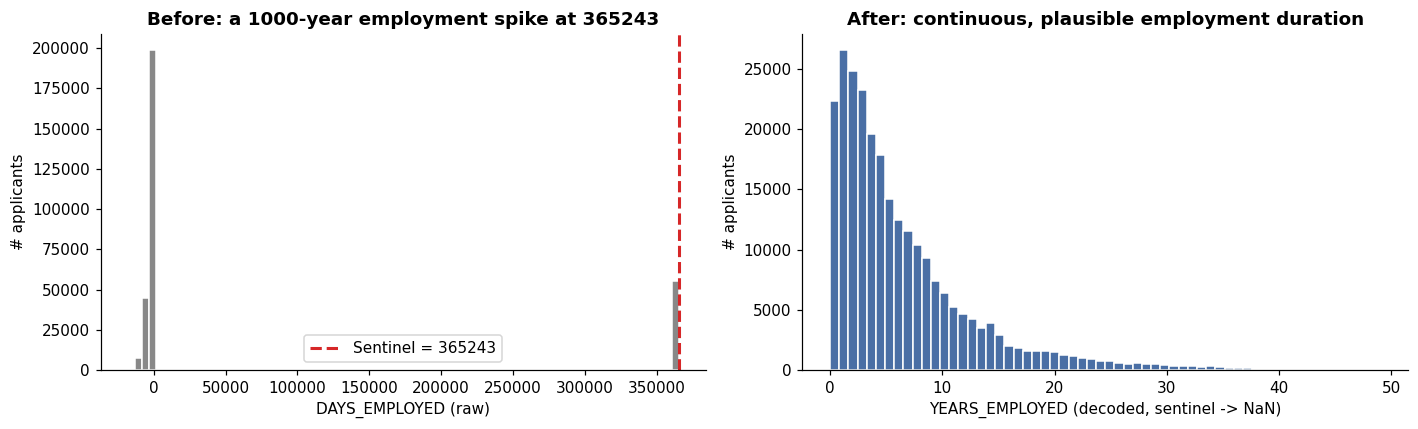

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ax = axes[0]
raw_days_emp = pd.read_csv('application_train.csv', usecols=['DAYS_EMPLOYED'])['DAYS_EMPLOYED']
ax.hist(raw_days_emp, bins=80, color=PAL['before'], edgecolor='white')
ax.axvline(365243, color=PAL['pos'], ls='--', lw=2, label='Sentinel = 365243')
ax.set_xlabel('DAYS_EMPLOYED (raw)')
ax.set_ylabel('# applicants')
ax.set_title('Before: a 1000-year employment spike at 365243')
ax.legend()

ax = axes[1]
ax.hist(df['YEARS_EMPLOYED'].dropna(), bins=60, color=PAL['after'], edgecolor='white')
ax.set_xlabel('YEARS_EMPLOYED (decoded, sentinel -> NaN)')
ax.set_ylabel('# applicants')
ax.set_title('After: continuous, plausible employment duration')

plt.tight_layout()
plt.show()

---
## Step 4 · Cap implausible numeric outliers

In [8]:
# Inspect a few suspect columns
for c in ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY',
          'CNT_CHILDREN', 'OBS_30_CNT_SOCIAL_CIRCLE',
          'OBS_60_CNT_SOCIAL_CIRCLE', 'DEF_30_CNT_SOCIAL_CIRCLE',
          'DEF_60_CNT_SOCIAL_CIRCLE']:
    s = df[c].dropna()
    print(f"{c:>30s}: p99={s.quantile(0.99):>10,.0f}  max={s.max():>12,.0f}  "
          f"(max/p99 = {s.max()/s.quantile(0.99):>5.1f}x)")

              AMT_INCOME_TOTAL: p99=   472,500  max= 117,000,000  (max/p99 = 247.6x)
                    AMT_CREDIT: p99= 1,854,000  max=   4,050,000  (max/p99 =   2.2x)
                   AMT_ANNUITY: p99=    70,006  max=     258,026  (max/p99 =   3.7x)
                  CNT_CHILDREN: p99=         3  max=          19  (max/p99 =   6.3x)
      OBS_30_CNT_SOCIAL_CIRCLE: p99=        10  max=         348  (max/p99 =  34.8x)
      OBS_60_CNT_SOCIAL_CIRCLE: p99=        10  max=         344  (max/p99 =  34.4x)
      DEF_30_CNT_SOCIAL_CIRCLE: p99=         2  max=          34  (max/p99 =  17.0x)
      DEF_60_CNT_SOCIAL_CIRCLE: p99=         2  max=          24  (max/p99 =  12.0x)


Two columns stand out:

- **`AMT_INCOME_TOTAL`**: max is **117,000,000** (vs p99 of 472,500 — a 247× gap). Looking at the top 10 incomes, only one is 117M, the next is 18M, then 13.5M. The 117M row is almost certainly a data-entry error (extra zeros).
- **`OBS_30_CNT_SOCIAL_CIRCLE`** (and `OBS_60`): max is **348** observed-people-in-social-circle, vs p99 of 10. A human cannot plausibly have 348 social contacts who got 30+ days past due. The next value is 47, so anything above 30 is suspect.

**Decision.** We **cap** rather than drop:
- Capping preserves the row's label and other features (we don't lose 250 income-millionaires worth of signal).
- We cap at the 99.9th percentile, not the 99th — we want to remove genuine errors, not just trim the right tail of the distribution.

In [9]:
def cap_at(s: pd.Series, q: float) -> pd.Series:
    """Cap a series at its qth quantile. Returns capped series + cap value."""
    cap = s.quantile(q)
    return s.clip(upper=cap), cap

caps_applied = {}

# AMT_INCOME_TOTAL: cap at 99.9th percentile
df['AMT_INCOME_TOTAL'], cap = cap_at(df['AMT_INCOME_TOTAL'], 0.999)
caps_applied['AMT_INCOME_TOTAL'] = cap
print(f"AMT_INCOME_TOTAL capped at {cap:,.0f}. New max = {df['AMT_INCOME_TOTAL'].max():,.0f}")

# Social-circle columns: cap at 99th percentile (much tighter — 348 is implausible)
for c in ['OBS_30_CNT_SOCIAL_CIRCLE', 'OBS_60_CNT_SOCIAL_CIRCLE',
          'DEF_30_CNT_SOCIAL_CIRCLE', 'DEF_60_CNT_SOCIAL_CIRCLE']:
    df[c], cap = cap_at(df[c], 0.99)
    caps_applied[c] = cap
    print(f"{c} capped at {cap:.0f}. New max = {df[c].max():.0f}")

# AMT_CREDIT max/p99 ratio is only 2.2 — no capping needed
# AMT_ANNUITY max/p99 ratio is 3.7 — borderline; we leave it alone, the model can handle it
# CNT_CHILDREN max=19 is plausible (large families exist)

AMT_INCOME_TOTAL capped at 900,000. New max = 900,000
OBS_30_CNT_SOCIAL_CIRCLE capped at 10. New max = 10
OBS_60_CNT_SOCIAL_CIRCLE capped at 10. New max = 10
DEF_30_CNT_SOCIAL_CIRCLE capped at 2. New max = 2
DEF_60_CNT_SOCIAL_CIRCLE capped at 2. New max = 2


### Visual confirmation: income tail before vs after

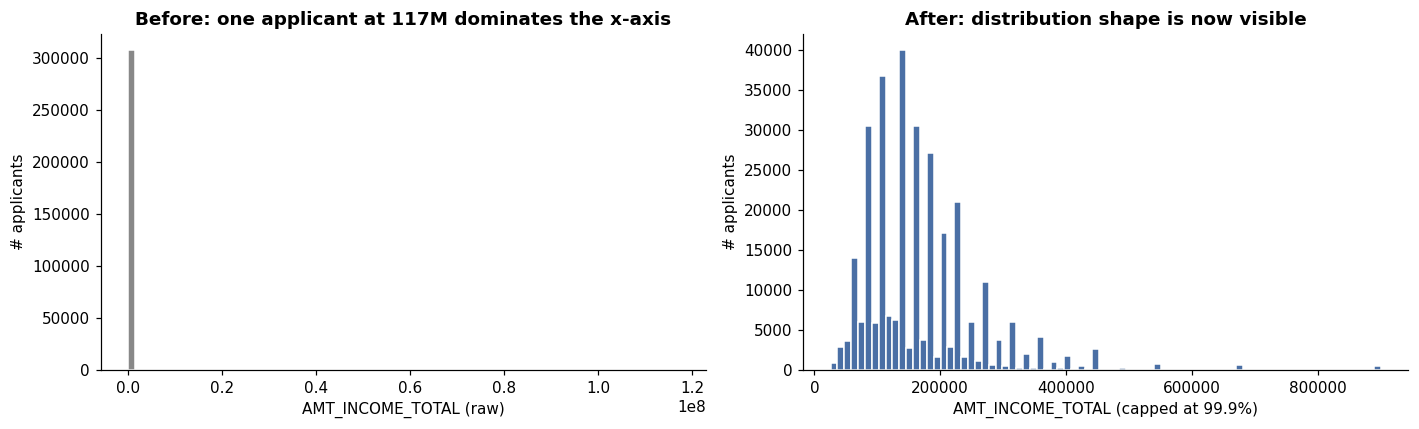

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

raw_inc = pd.read_csv('application_train.csv', usecols=['AMT_INCOME_TOTAL'])['AMT_INCOME_TOTAL']

ax = axes[0]
ax.hist(raw_inc, bins=80, color=PAL['before'], edgecolor='white')
ax.set_xlabel('AMT_INCOME_TOTAL (raw)')
ax.set_ylabel('# applicants')
ax.set_title('Before: one applicant at 117M dominates the x-axis')

ax = axes[1]
ax.hist(df['AMT_INCOME_TOTAL'], bins=80, color=PAL['after'], edgecolor='white')
ax.set_xlabel('AMT_INCOME_TOTAL (capped at 99.9%)')
ax.set_ylabel('# applicants')
ax.set_title('After: distribution shape is now visible')

plt.tight_layout()
plt.show()

---
## Step 5 · Structured missing-value handling


In [11]:
# Step 5a — Housing-block indicator
housing_cols = [c for c in df.columns if any(
    k in c for k in ['APARTMENTS','BASEMENTAREA','YEARS_BUILD',
                     'COMMONAREA','ELEVATORS','ENTRANCES','FLOORS',
                     'LANDAREA','LIVING','NONLIVING','YEARS_BEGIN',
                     'TOTALAREA','FONDKAPREMONT','HOUSETYPE',
                     'WALLSMATERIAL','EMERGENCYSTATE'])]
print(f"Housing-block columns identified: {len(housing_cols)}")

df['HAS_HOUSING_DATA'] = df['APARTMENTS_AVG'].notna().astype('int8')
hd_rate = df.groupby('HAS_HOUSING_DATA')['TARGET'].mean() * 100
print(f"\nDefault rate by indicator value:")
print(f"  HAS_HOUSING_DATA = 0 (no housing data): {hd_rate[0]:.2f}%")
print(f"  HAS_HOUSING_DATA = 1 (has housing data): {hd_rate[1]:.2f}%")
print(f"  Relative risk: {hd_rate[0]/hd_rate[1]:.2f}x")

Housing-block columns identified: 47

Default rate by indicator value:
  HAS_HOUSING_DATA = 0 (no housing data): 9.15%
  HAS_HOUSING_DATA = 1 (has housing data): 6.96%
  Relative risk: 1.32x


In [12]:
# Step 5b — Identify column types for imputation
# Treat int columns that are actually 0/1 flags as categorical for imputation
flag_cols = [c for c in df.columns if c.startswith('FLAG_')]

num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
# Don't impute the target or the indicators we just made
exclude = {'SK_ID_CURR', 'TARGET', 'DAYS_EMPLOYED_IS_ANOM', 'HAS_HOUSING_DATA'}
num_cols_to_impute = [c for c in num_cols if c not in exclude and c not in flag_cols]
cat_cols = df.select_dtypes(include=['object']).columns.tolist()

print(f"Numeric columns to impute:     {len(num_cols_to_impute)}")
print(f"Categorical columns to impute: {len(cat_cols)}")
print(f"FLAG_ columns (already 0/1, no NaN expected): {len(flag_cols)}")

# Sanity check: FLAG columns should have no NaN
flag_nan = {c: df[c].isna().sum() for c in flag_cols if df[c].isna().sum() > 0}
print(f"FLAG_ columns with NaN: {flag_nan if flag_nan else 'none'}")

Numeric columns to impute:     83
Categorical columns to impute: 16
FLAG_ columns (already 0/1, no NaN expected): 28
FLAG_ columns with NaN: none


In [13]:
# Step 5c — Compute imputation values from the data we have (no leakage to test
# would happen here because we are only processing the training set)
imputation_values = {}
for c in num_cols_to_impute:
    imputation_values[c] = df[c].median()
for c in cat_cols:
    imputation_values[c] = 'Unknown'

# Apply
miss_before = df[num_cols_to_impute + cat_cols].isna().sum().sum()
df[num_cols_to_impute] = df[num_cols_to_impute].fillna(
    pd.Series({c: imputation_values[c] for c in num_cols_to_impute})
)
df[cat_cols] = df[cat_cols].fillna(
    pd.Series({c: imputation_values[c] for c in cat_cols})
)
miss_after = df[num_cols_to_impute + cat_cols].isna().sum().sum()

print(f"Missing cells imputed: {miss_before:,} -> {miss_after}")
print(f"\nTotal NaN remaining anywhere in df: {df.isna().sum().sum()}")

Missing cells imputed: 9,318,512 -> 0



Total NaN remaining anywhere in df: 0


### Visual: missingness map, before vs after

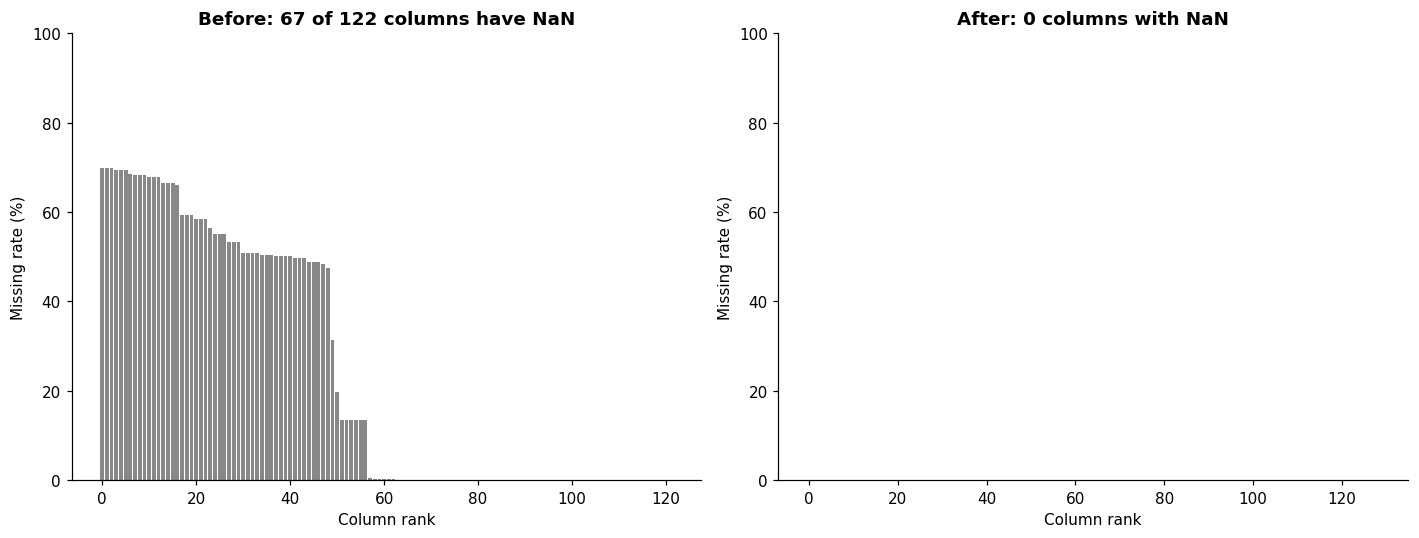

In [14]:
# Reload raw for a fair "before" picture
raw = pd.read_csv('application_train.csv')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ax = axes[0]
miss_before_pct = raw.isna().mean().sort_values(ascending=False)
ax.bar(range(len(miss_before_pct)), miss_before_pct.values * 100,
       color=PAL['before'])
ax.set_xlabel('Column rank')
ax.set_ylabel('Missing rate (%)')
ax.set_title(f'Before: {(miss_before_pct>0).sum()} of {len(miss_before_pct)} columns have NaN')
ax.set_ylim(0, 100)

ax = axes[1]
miss_after_pct = df.isna().mean().sort_values(ascending=False)
ax.bar(range(len(miss_after_pct)), miss_after_pct.values * 100,
       color=PAL['after'])
ax.set_xlabel('Column rank')
ax.set_ylabel('Missing rate (%)')
ax.set_title(f'After: {(miss_after_pct>0).sum()} columns with NaN')
ax.set_ylim(0, 100)

plt.tight_layout()
plt.show()

---
## Step 6 · Type fixes & memory downcast

In [15]:
def downcast_numeric(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    for c in df.select_dtypes(include=['int64', 'int32']).columns:
        df[c] = pd.to_numeric(df[c], downcast='integer')
    for c in df.select_dtypes(include=['float64', 'float32']).columns:
        df[c] = pd.to_numeric(df[c], downcast='float')
    return df

mem_before = df.memory_usage(deep=True).sum() / 1e6
df = downcast_numeric(df)

# Convert object columns to pandas categorical
for c in df.select_dtypes(include=['object']).columns:
    df[c] = df[c].astype('category')

mem_after = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory before downcast: {mem_before:.0f} MB")
print(f"Memory after  downcast: {mem_after:.0f} MB")
print(f"Reduction:              {(1-mem_after/mem_before)*100:.0f}%")

Memory before downcast: 563 MB
Memory after  downcast: 110 MB
Reduction:              80%


In [16]:
# Show the dtype distribution
print("Dtype counts after cleaning:")
print(df.dtypes.value_counts())

Dtype counts after cleaning:
float32     70
int8        39
category     2
int16        2
int32        1
category     1
category     1
float64      1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


---
## Step 7 · Final consistency checks & save

In [17]:
checks = {}

# 1. Row count
checks['rows_match'] = len(df) == snapshot['rows'] - 4

# 2. Target distribution preserved (we only dropped 4 rows, both class-0)
new_rate = df['TARGET'].mean()
checks['target_rate_close'] = abs(new_rate - snapshot['default_rate']) < 0.001

# 3. No NaN anywhere
checks['no_nan'] = df.isna().sum().sum() == 0

# 4. Consistency: children <= family members
checks['children_le_family'] = (df['CNT_CHILDREN'] <= df['CNT_FAM_MEMBERS']).all()

# 5. Ages in plausible range
checks['ages_plausible'] = (df['AGE_YEARS'].between(18, 100)).all()

# 6. Indicators are 0/1
checks['indicators_binary'] = (
    df['DAYS_EMPLOYED_IS_ANOM'].isin([0,1]).all()
    and df['HAS_HOUSING_DATA'].isin([0,1]).all()
)

print("Consistency checks:")
for name, ok in checks.items():
    flag = 'OK ' if ok else 'FAIL'
    print(f"  [{flag}] {name}")

assert all(checks.values()), "A consistency check failed!"
print("\nAll checks passed.")

Consistency checks:
  [OK ] rows_match
  [OK ] target_rate_close
  [OK ] no_nan
  [OK ] children_le_family
  [OK ] ages_plausible
  [OK ] indicators_binary

All checks passed.


In [18]:
# Save the cleaned dataframe and the artifacts that downstream notebooks need
df.to_csv('application_train_clean.csv', index=False)
print(f"Saved application_train_clean.csv  ({df.shape[0]:,} x {df.shape[1]})")

# Save imputation values and caps for reuse on the test set
import json
artifacts = {
    'imputation_values': {k: (float(v) if isinstance(v, (int, float, np.number)) else v)
                          for k, v in imputation_values.items()},
    'caps_applied': {k: float(v) for k, v in caps_applied.items()},
    'rows_dropped': int(snapshot['rows'] - len(df)),
    'indicators_created': ['DAYS_EMPLOYED_IS_ANOM', 'HAS_HOUSING_DATA'],
    'derived_columns': ['AGE_YEARS', 'YEARS_EMPLOYED', 'YEARS_REGISTRATION',
                        'YEARS_ID_PUBLISH', 'YEARS_LAST_PHONE_CHANGE'],
}
with open('cleaning_artifacts.json', 'w') as f:
    json.dump(artifacts, f, indent=2, default=str)
print("Saved cleaning_artifacts.json")

Saved application_train_clean.csv  (307,507 x 129)
Saved cleaning_artifacts.json


---
## Summary — Before vs after

In [19]:
summary = pd.DataFrame({
    'Metric': ['Rows', 'Columns', 'Memory (MB)', 'Default rate (%)',
               'Total NaN cells', 'XNA-gender rows', 'DAYS_EMPLOYED sentinel rows',
               'AMT_INCOME_TOTAL max'],
    'Before': [snapshot['rows'], snapshot['cols'],
               f"{snapshot['memory_mb']:.0f}",
               f"{snapshot['default_rate']*100:.2f}",
               f"{int(raw.isna().sum().sum()):,}",
               4, 55374,
               f"{raw['AMT_INCOME_TOTAL'].max():,.0f}"],
    'After':  [len(df), df.shape[1],
               f"{df.memory_usage(deep=True).sum()/1e6:.0f}",
               f"{df['TARGET'].mean()*100:.2f}",
               int(df.isna().sum().sum()),
               0, 0,
               f"{df['AMT_INCOME_TOTAL'].max():,.0f}"],
})
summary

,Metric,Before,After
0,Rows,307511,307507
1,Columns,122,129
2,Memory (MB),530,110
3,Default rate (%),8.07,8.07
4,Total NaN cells,"9,152,465",0
5,XNA-gender rows,4,0
6,DAYS_EMPLOYED sentinel rows,55374,0
7,AMT_INCOME_TOTAL max,"117,000,000","900,000"
